### **Partie 1 — Chargement et exploration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Chargement du dataset
iris = load_iris()

In [7]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [10]:
iris['filename']

'iris.csv'

In [2]:
# Construction du DataFrame
df = pd.DataFrame(iris.data, columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])
df["Species"] = [iris.target_names[i] for i in iris.target]

In [13]:
print("=== 5 premières lignes ===")
display(df.head(3))

print("\n=== 5 dernières lignes ===")
display(df.tail())

=== 5 premières lignes ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa



=== 5 dernières lignes ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [14]:

# Forme du DataFrame
print("Shape:", df.shape)
print(f"\n{df.shape[0]} lignes, {df.shape[1]} colonnes")

Shape: (150, 5)

150 lignes, 5 colonnes


In [15]:

# Info et describe
print("=== df.info() ===")
df.info()

print("\n=== df.describe() ===")
display(df.describe())


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB

=== df.describe() ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
print("\n=== Types de données ===")
print(df.dtypes)


=== Types de données ===
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


### **Partie 2 — Sélections et indexation**

In [17]:
# 1. Sélection de colonnes
print("=== Colonnes SepalLengthCm et PetalLengthCm ===")
display(df[["SepalLengthCm", "PetalLengthCm"]].head())

=== Colonnes SepalLengthCm et PetalLengthCm ===


,SepalLengthCm,PetalLengthCm
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


In [18]:
# 2. loc[] : sélection par labels
print("=== loc[10:20, ['Species', 'PetalWidthCm']] ===")
display(df.loc[10:20, ["Species", "PetalWidthCm"]])

=== loc[10:20, ['Species', 'PetalWidthCm']] ===


,Species,PetalWidthCm
10,setosa,0.2
11,setosa,0.2
12,setosa,0.1
13,setosa,0.1
14,setosa,0.2
15,setosa,0.4
16,setosa,0.4
17,setosa,0.3
18,setosa,0.3
19,setosa,0.3


In [19]:
# 3. iloc[] : sélection par position
print("=== iloc[:5, :2] (5 premières lignes, 2 premières colonnes) ===")
display(df.iloc[:5, :2])

=== iloc[:5, :2] (5 premières lignes, 2 premières colonnes) ===


,SepalLengthCm,SepalWidthCm
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [20]:
# 4. Filtrage simple
print("=== Fleurs avec SepalLengthCm > 6.0 ===")
df_grand = df[df["SepalLengthCm"] > 6.0]
print(f"{len(df_grand)} fleurs trouvées")
display(df_grand.head())

=== Fleurs avec SepalLengthCm > 6.0 ===
61 fleurs trouvées


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
56,6.3,3.3,4.7,1.6,versicolor


In [21]:
# 5. Filtrage avec plusieurs conditions
print("=== SepalLengthCm > 5.5 ET PetalLengthCm < 4.0 ===")
df_filtre = df[(df["SepalLengthCm"] > 5.5) & (df["PetalLengthCm"] < 4.0)]
print(f"{len(df_filtre)} fleurs trouvées")
display(df_filtre.head())

=== SepalLengthCm > 5.5 ET PetalLengthCm < 4.0 ===
7 fleurs trouvées


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
14,5.8,4.0,1.2,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
18,5.7,3.8,1.7,0.3,setosa
64,5.6,2.9,3.6,1.3,versicolor
69,5.6,2.5,3.9,1.1,versicolor


In [22]:
# 6. Méthode query()
print("=== Espèce versicolor avec query() ===")
df_versicolor = df.query("Species == 'versicolor'")
print(f"{len(df_versicolor)} fleurs versicolor")
display(df_versicolor.head())

=== Espèce versicolor avec query() ===
50 fleurs versicolor


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


### **Partie 3 — Manipulation des colonnes et lignes**


In [3]:
# Travail sur une copie pour ne pas modifier l'original
df_work = df.copy()

# 1. Ajout de PetalRatio
df_work["PetalRatio"] = df_work["PetalLengthCm"] / df_work["PetalWidthCm"]
print("=== Nouvelles colonnes ajoutées ===")
display(df_work.head())

=== Nouvelles colonnes ajoutées ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio
0,5.1,3.5,1.4,0.2,setosa,7.0
1,4.9,3.0,1.4,0.2,setosa,7.0
2,4.7,3.2,1.3,0.2,setosa,6.5
3,4.6,3.1,1.5,0.2,setosa,7.5
4,5.0,3.6,1.4,0.2,setosa,7.0


In [4]:
# 2. Ajout de SepalArea
df_work["SepalArea"] = df_work["SepalLengthCm"] * df_work["SepalWidthCm"]
print("=== Nouvelles colonnes ajoutées ===")
display(df_work.head())

=== Nouvelles colonnes ajoutées ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio,SepalArea
0,5.1,3.5,1.4,0.2,setosa,7.0,17.85
1,4.9,3.0,1.4,0.2,setosa,7.0,14.70
2,4.7,3.2,1.3,0.2,setosa,6.5,15.04
3,4.6,3.1,1.5,0.2,setosa,7.5,14.26
4,5.0,3.6,1.4,0.2,setosa,7.0,18.00


In [5]:
# 3. Colonne catégorielle Taille
def categorize_size(length):
    if length < 5.0:
        return "petite"
    elif length < 6.5:
        return "moyenne"
    else:
        return "grande"

df_work["Taille"] = df_work["SepalLengthCm"].apply(categorize_size)
display(df_work.head())
# Alternative avec np.select (plus efficace)
# conditions = [
#     df_work["SepalLengthCm"] < 5.0,
#     df_work["SepalLengthCm"] < 6.5
# ]
# choices = ["petite", "moyenne"]
# df_work["Taille"] = np.select(conditions, choices, default="grande")


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio,SepalArea,Taille
0,5.1,3.5,1.4,0.2,setosa,7.0,17.85,moyenne
1,4.9,3.0,1.4,0.2,setosa,7.0,14.70,petite
2,4.7,3.2,1.3,0.2,setosa,6.5,15.04,petite
3,4.6,3.1,1.5,0.2,setosa,7.5,14.26,petite
4,5.0,3.6,1.4,0.2,setosa,7.0,18.00,moyenne


In [ ]:

print("=== Distribution des tailles ===")
print(df_work["Taille"].value_counts())

In [6]:
# 4. Suppression de la colonne SepalArea
df_work = df_work.drop(columns=["SepalArea"])
print("Colonnes après suppression:", list(df_work.columns))

Colonnes après suppression: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species', 'PetalRatio', 'Taille']


In [7]:
# 5. Suppression des lignes où SepalLengthCm < 5.0
print(f"Avant suppression: {len(df_work)} lignes")
df_work = df_work[df_work["SepalLengthCm"] >= 5.0]
print(f"Après suppression: {len(df_work)} lignes")

Avant suppression: 150 lignes
Après suppression: 128 lignes


In [28]:
# 6. Tri par PetalLengthCm décroissant
df_work = df_work.sort_values(by="PetalLengthCm", ascending=False)
print("=== Trié par PetalLengthCm décroissant ===")
display(df_work.head())

=== Trié par PetalLengthCm décroissant ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio,Taille
118,7.7,2.6,6.9,2.3,virginica,3.000000,grande
117,7.7,3.8,6.7,2.2,virginica,3.045455,grande
122,7.7,2.8,6.7,2.0,virginica,3.350000,grande
105,7.6,3.0,6.6,2.1,virginica,3.142857,grande
131,7.9,3.8,6.4,2.0,virginica,3.200000,grande


In [8]:
# 7. Réinitialisation de l'index
df_work = df_work.reset_index(drop=True)
print("=== Index réinitialisé ===")
display(df_work.head())

=== Index réinitialisé ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio,Taille
0,5.1,3.5,1.4,0.2,setosa,7.00,moyenne
1,5.0,3.6,1.4,0.2,setosa,7.00,moyenne
2,5.4,3.9,1.7,0.4,setosa,4.25,moyenne
3,5.0,3.4,1.5,0.2,setosa,7.50,moyenne
4,5.4,3.7,1.5,0.2,setosa,7.50,moyenne


### **Partie 4 — Gestion des valeurs manquantes**

In [9]:
# Travail sur une nouvelle copie
df_nan = df.copy()

# 1. Introduction de NaN artificiels
np.random.seed(42)  # Pour reproductibilité
indices_nan = df_nan.sample(5).index
df_nan.loc[indices_nan, "PetalWidthCm"] = np.nan

print(f"Indices avec NaN: {list(indices_nan)}")

Indices avec NaN: [73, 18, 118, 78, 76]


In [10]:
# 2. Compter les valeurs manquantes
print("=== Valeurs manquantes par colonne ===")
print(df_nan.isna().sum())

=== Valeurs manquantes par colonne ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     5
Species          0
dtype: int64


In [11]:
# 3. Afficher les lignes avec NaN
print("=== Lignes contenant des NaN ===")
display(df_nan[df_nan.isna().any(axis=1)])

=== Lignes contenant des NaN ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
18,5.7,3.8,1.7,NaN,setosa
73,6.1,2.8,4.7,NaN,versicolor
76,6.8,2.8,4.8,NaN,versicolor
78,6.0,2.9,4.5,NaN,versicolor
118,7.7,2.6,6.9,NaN,virginica


In [12]:
# 4. Remplacement par la moyenne
mean_petal_width = df_nan["PetalWidthCm"].mean()
print(f"Moyenne de PetalWidthCm: {mean_petal_width:.3f}")

df_filled = df_nan.copy()
df_filled["PetalWidthCm"] = df_filled["PetalWidthCm"].fillna(mean_petal_width)

print("\nAprès fillna:")
print(df_filled.isna().sum())

Moyenne de PetalWidthCm: 1.194

Après fillna:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [13]:
# 5. Suppression des lignes avec NaN (sur une copie)
df_dropped = df_nan.dropna()
print(f"Avant dropna: {len(df_nan)} lignes")
print(f"Après dropna: {len(df_dropped)} lignes")

Avant dropna: 150 lignes
Après dropna: 145 lignes


### **Partie 5 — Agrégations et groupby**

In [18]:
# 1. Comptage par espèce
print("=== Occurrences par espèce ===")
print(df["Species"].value_counts())

=== Occurrences par espèce ===
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [19]:
# 2. Moyenne par espèce
print("=== Moyenne par espèce ===")
display(df.groupby("Species").mean(numeric_only=True))

=== Moyenne par espèce ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [20]:
# 3. Plusieurs statistiques par espèce
print("=== Statistiques multiples par espèce ===")
stats = df.groupby("Species").agg(["mean", "std", "min", "max"])
display(stats)

=== Statistiques multiples par espèce ===


SepalLengthCm                     SepalWidthCm                      \
                    mean       std  min  max         mean       std  min  max   
Species                                                                         
setosa             5.006  0.352490  4.3  5.8        3.428  0.379064  2.3  4.4   
versicolor         5.936  0.516171  4.9  7.0        2.770  0.313798  2.0  3.4   
virginica          6.588  0.635880  4.9  7.9        2.974  0.322497  2.2  3.8   

           PetalLengthCm                     PetalWidthCm                      
                    mean       std  min  max         mean       std  min  max  
Species                                                                        
setosa             1.462  0.173664  1.0  1.9        0.246  0.105386  0.1  0.6  
versicolor         4.260  0.469911  3.0  5.1        1.326  0.197753  1.0  1.8  
virginica          5.552  0.551895  4.5  6.9        2.026  0.274650  1.4  2.5

In [21]:
# 4. Percentiles par espèce
print("=== Percentiles de PetalLengthCm par espèce ===")
percentiles = df.groupby("Species")["PetalLengthCm"].quantile([0.25, 0.5, 0.75]).unstack()
percentiles.columns = ["Q1 (25%)", "Médiane (50%)", "Q3 (75%)"]
display(percentiles)

=== Percentiles de PetalLengthCm par espèce ===


,Q1 (25%),Médiane (50%),Q3 (75%)
Species,,,
setosa,1.4,1.50,1.575
versicolor,4.0,4.35,4.600
virginica,5.1,5.55,5.875


In [22]:
# 5. Tableau croisé Species x Taille
# D'abord ajouter la colonne Taille
df_with_size = df.copy()
df_with_size["Taille"] = df_with_size["SepalLengthCm"].apply(
    lambda x: "petite" if x < 5.0 else ("moyenne" if x < 6.5 else "grande")
)

print("=== Tableau croisé Species × Taille ===")
cross_tab = pd.crosstab(df_with_size["Species"], df_with_size["Taille"])
display(cross_tab)

=== Tableau croisé Species × Taille ===


Taille,grande,moyenne,petite
Species,,,
setosa,0,30,20
versicolor,9,40,1
virginica,26,23,1


### **Partie 6 — Lecture/écriture de fichiers**

In [23]:
# 1. Export en CSV
df.to_csv("iris_enrichi.csv", index=False)
print("Fichier iris_enrichi.csv créé !")

Fichier iris_enrichi.csv créé !


In [24]:
# 2. Rechargement du CSV
df_reload = pd.read_csv("iris_enrichi.csv")
print("=== Fichier rechargé ===")
display(df_reload.head())

=== Fichier rechargé ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
# 3. Vérification d'égalité
print("DataFrames identiques ?", df.equals(df_reload))

# Comparaison plus détaillée si nécessaire
print(f"Mêmes shapes: {df.shape == df_reload.shape}")
print(f"Mêmes colonnes: {list(df.columns) == list(df_reload.columns)}")

DataFrames identiques ? True
Mêmes shapes: True
Mêmes colonnes: True


In [26]:
# 4. Export avec séparateur ;
df.to_csv("iris_semicolon.csv", index=False, sep=";")

# Rechargement avec le bon séparateur
df_semicolon = pd.read_csv("iris_semicolon.csv", sep=";")
print("=== Rechargement avec sep=';' ===")
display(df_semicolon.head())

=== Rechargement avec sep=';' ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### **Partie 7 — Visualisations**

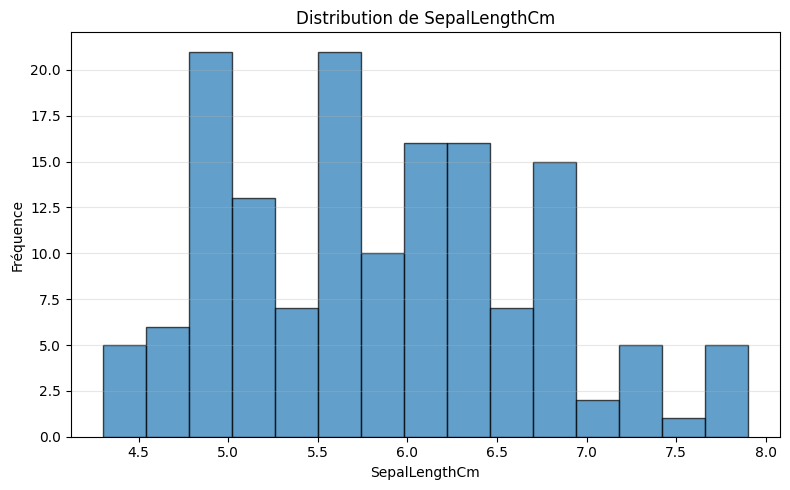

In [27]:
# 7.1 Histogramme
plt.figure(figsize=(8, 5))
plt.hist(df["SepalLengthCm"], bins=15, edgecolor="black", alpha=0.7)
plt.title("Distribution de SepalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("Fréquence")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

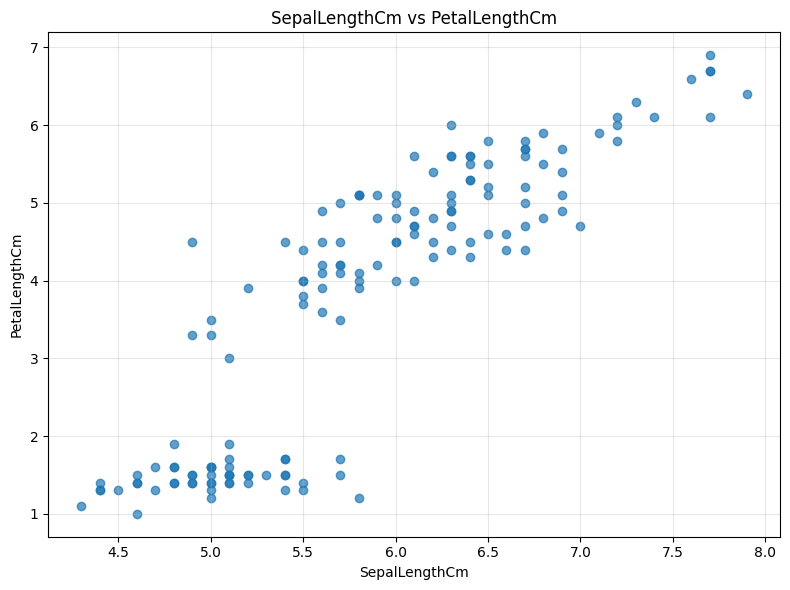

In [28]:
# 7.2 Nuage de points simple
plt.figure(figsize=(8, 6))
plt.scatter(df["SepalLengthCm"], df["PetalLengthCm"], alpha=0.7)
plt.title("SepalLengthCm vs PetalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalLengthCm")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

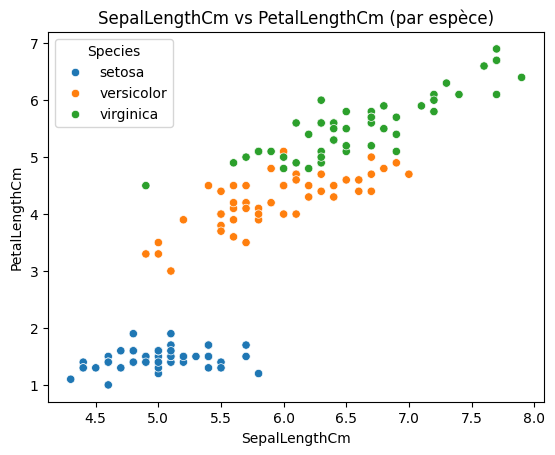

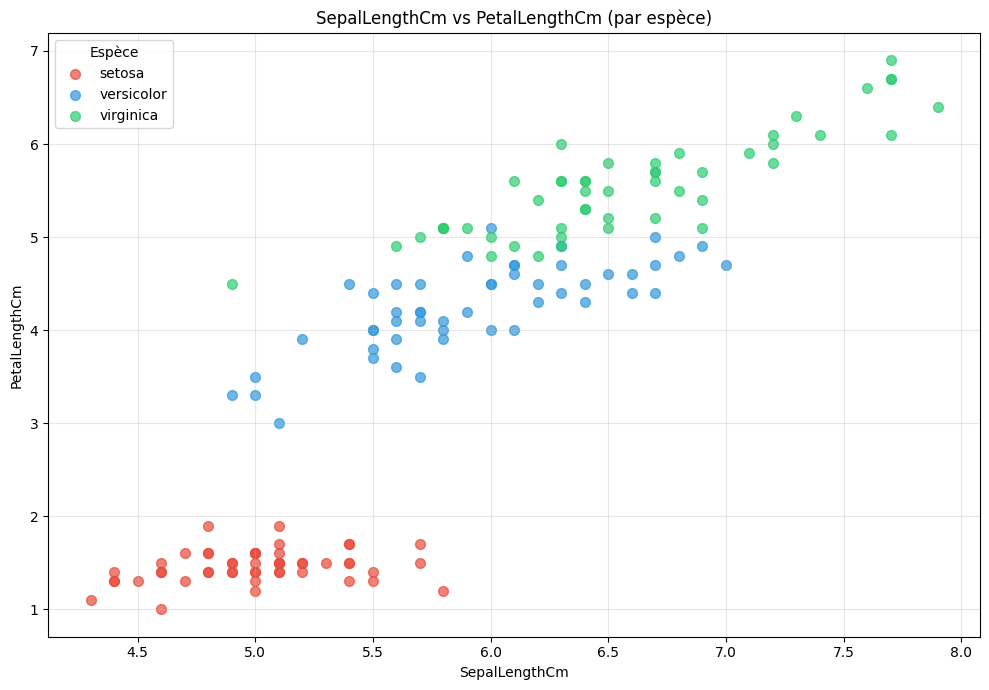

In [29]:
# 7.3 Nuage de points coloré par espèce

# Avec seaborn (plus simple pour les couleurs et légendes)
sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="PetalLengthCm",
    hue="Species"
)
plt.title("SepalLengthCm vs PetalLengthCm (par espèce)")
plt.show()



# Avec matplotlib (plus de contrôle sur les couleurs)
colors = {"setosa": "#e74c3c", "versicolor": "#3498db", "virginica": "#2ecc71"}

plt.figure(figsize=(10, 7))
for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(
        subset["SepalLengthCm"],
        subset["PetalLengthCm"],
        c=colors[species],
        label=species,
        alpha=0.7,
        s=50
    )

plt.title("SepalLengthCm vs PetalLengthCm (par espèce)")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalLengthCm")
plt.legend(title="Espèce")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

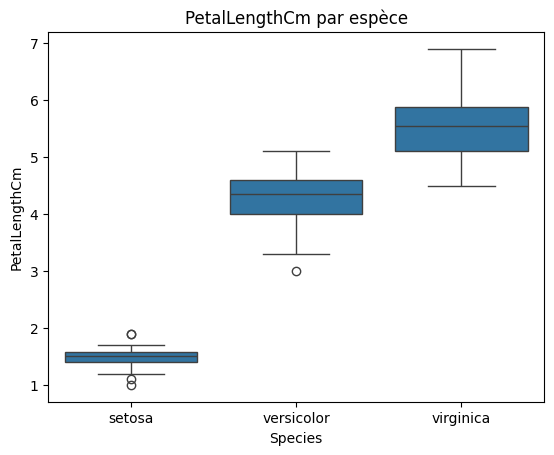

C:\Users\naouf\AppData\Local\Temp\ipykernel_43064\1868139419.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_species, labels=species_list, patch_artist=True)


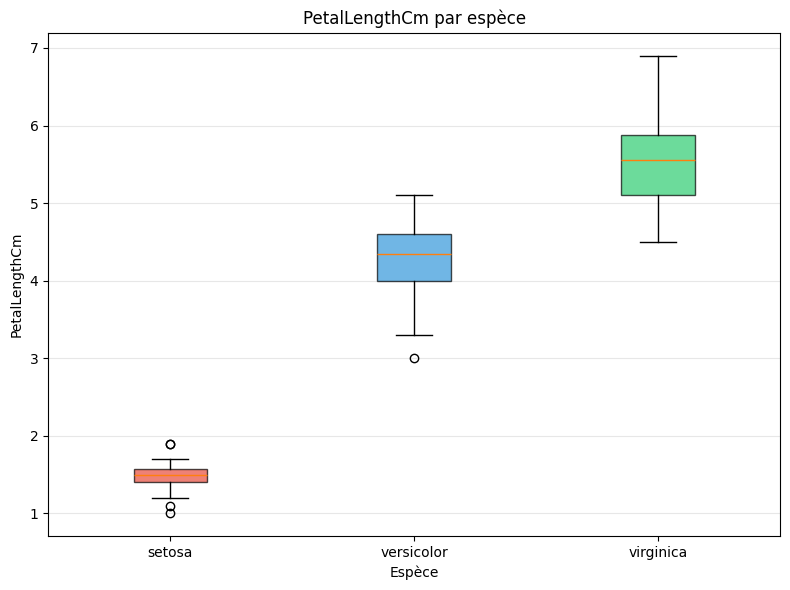

In [30]:
# 7.4 Boxplots par espèce

# Avec seaborn (très simple)
sns.boxplot(
    data=df,
    x="Species",
    y="PetalLengthCm"
)
plt.title("PetalLengthCm par espèce")
plt.show()


# Avec matplotlib (plus de personnalisation)
species_list = sorted(df["Species"].unique())
data_by_species = [df[df["Species"] == sp]["PetalLengthCm"].values for sp in species_list]

plt.figure(figsize=(8, 6))
bp = plt.boxplot(data_by_species, labels=species_list, patch_artist=True)

# Coloration des boîtes
box_colors = ["#e74c3c", "#3498db", "#2ecc71"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("PetalLengthCm par espèce")
plt.xlabel("Espèce")
plt.ylabel("PetalLengthCm")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
counts = df["Species"].value_counts()
counts

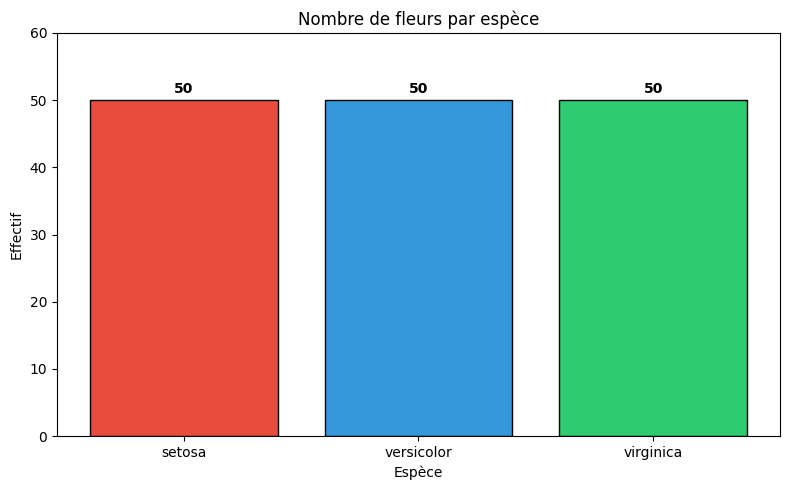

C:\Users\naouf\AppData\Local\Temp\ipykernel_43064\2464218323.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


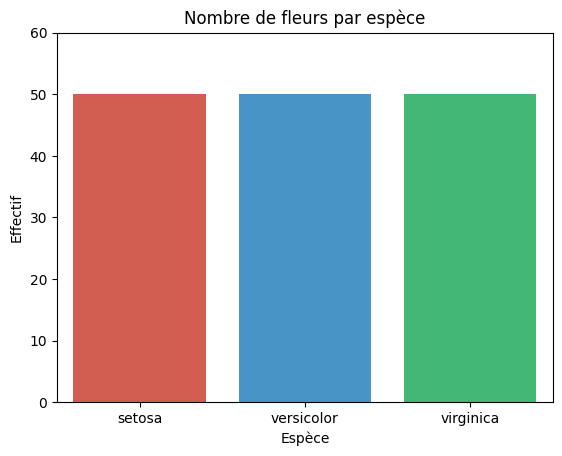

In [31]:
# 7.5 Diagramme en barres

# Avec matplotlib
counts = df["Species"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#e74c3c", "#3498db", "#2ecc71"], edgecolor="black")

# Ajout des valeurs sur les barres
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha="center", fontweight="bold")

plt.title("Nombre de fleurs par espèce")
plt.xlabel("Espèce")
plt.ylabel("Effectif")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()


# Avec seaborn (plus simple pour les couleurs et les étiquettes)
counts = df["Species"].value_counts().reset_index()
counts.columns = ["Species", "count"]

sns.barplot(
    data=counts,
    x="Species",
    y="count",
    palette=["#e74c3c", "#3498db", "#2ecc71"]
)

plt.title("Nombre de fleurs par espèce")
plt.xlabel("Espèce")
plt.ylabel("Effectif")
plt.ylim(0, 60)

plt.show()

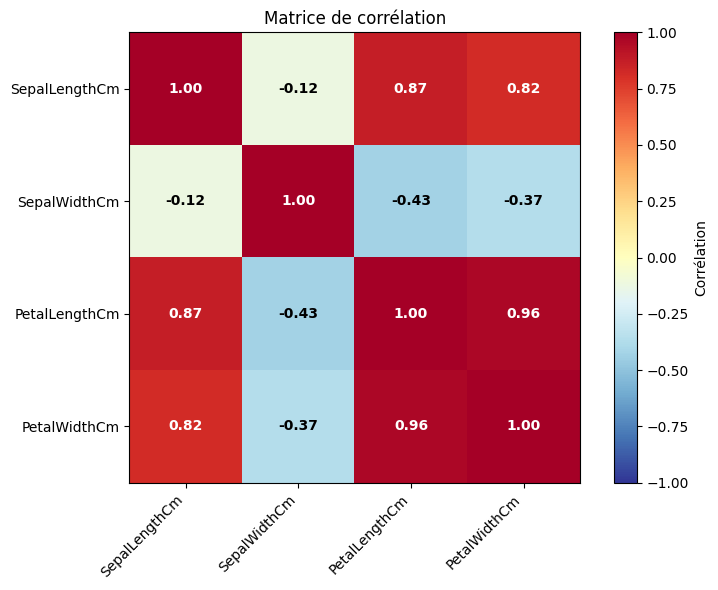

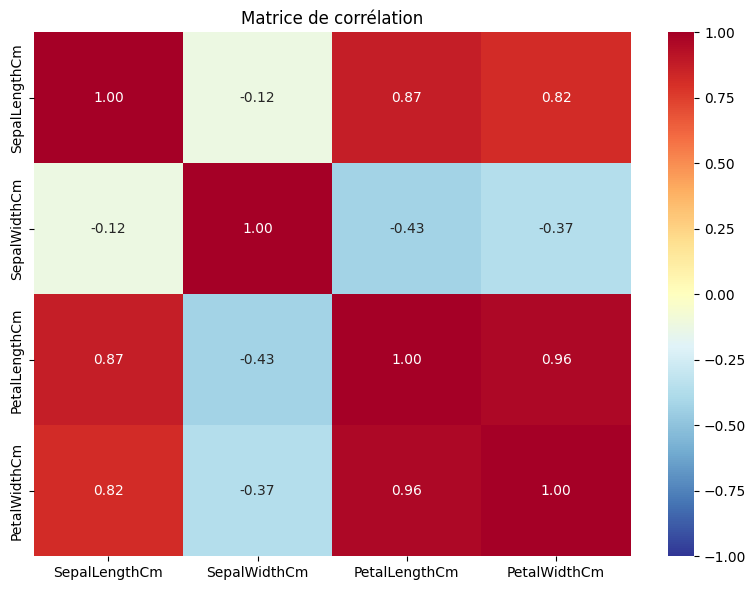

In [32]:
# 7.6 Matrice de corrélation

# Avec matplotlib
numeric_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap="RdYlBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Corrélation")

# Labels
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Valeurs dans les cellules
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = f"{corr_matrix.iloc[i, j]:.2f}"
        plt.text(j, i, text, ha="center", va="center", fontweight="bold",
                 color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


# Avec seaborn

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # affiche les valeurs
    fmt=".2f",           # 2 décimales
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

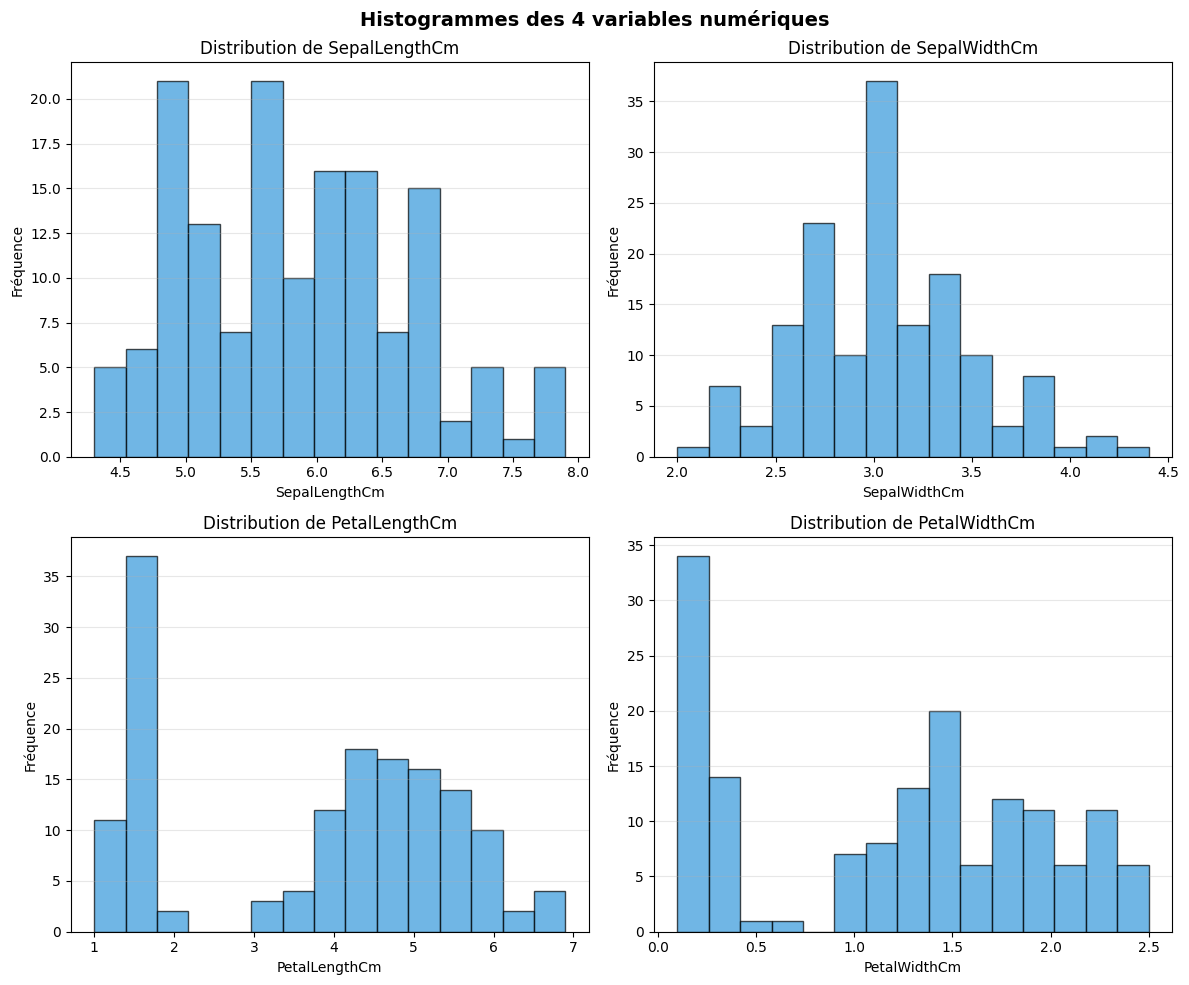

In [33]:
# 7.7 Subplots multiples (2x2 histogrammes)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df[col], bins=15, edgecolor="black", alpha=0.7, color="#3498db")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Histogrammes des 4 variables numériques", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **Partie 8 — Exercices bonus**

In [ ]:
# Bonus 1 : Outlier avec le plus grand PetalRatio
df_bonus = df.copy()
df_bonus["PetalRatio"] = df_bonus["PetalLengthCm"] / df_bonus["PetalWidthCm"]

idx_max = df_bonus["PetalRatio"].idxmax()
print("=== Fleur avec le plus grand PetalRatio ===")
display(df_bonus.loc[[idx_max]])

print(f"\nPetalRatio max: {df_bonus.loc[idx_max, 'PetalRatio']:.2f}")
print("C'est une fleur setosa, ce qui est cohérent car les setosa ont des pétales très fins.")

In [ ]:
# Bonus 2 : Coefficient de variation par espèce
def coef_variation(x):
    return x.std() / x.mean() * 100  # En pourcentage

cv_by_species = df.groupby("Species")[numeric_cols].apply(coef_variation)
print("=== Coefficient de variation (%) par espèce ===")
display(cv_by_species.round(2))

In [ ]:
# Bonus 3 : Fleurs "typiques"
# Une fleur est typique si toutes ses mesures sont dans mean ± 1 std de son espèce

def is_typical(row):
    species = row["Species"]
    species_data = df[df["Species"] == species][numeric_cols]
    means = species_data.mean()
    stds = species_data.std()

    for col in numeric_cols:
        if not (means[col] - stds[col] <= row[col] <= means[col] + stds[col]):
            return False
    return True

df_bonus["Typique"] = df_bonus.apply(is_typical, axis=1)

print("=== Fleurs typiques vs atypiques ===")
print(df_bonus["Typique"].value_counts())
print(f"\n{df_bonus['Typique'].mean()*100:.1f}% des fleurs sont typiques")

In [ ]:
# Nettoyage des fichiers temporaires
import os
for f in ["iris_enrichi.csv", "iris_semicolon.csv"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Fichier {f} supprimé.")